In [2]:
# ── Project 2: Menu Engineering & Revenue Analysis ──
# Restaurant: Goomti | Analyst: [Piyush] | Date: June 2026

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [4]:
import os
print(os.getcwd())

C:\Users\piyus\Downloads


In [5]:
# ── Load Data ──
df_items = pd.read_csv('dim_menu_items.csv')
df_categories = pd.read_csv('dim_categories.csv')

# Quick inspection
print("=== Menu Items ===")
print(f"Shape: {df_items.shape}")
print(f"Columns: {df_items.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df_items.head())

print(f"\n=== Categories ===")
print(f"Shape: {df_categories.shape}")
print(df_categories.head())

=== Menu Items ===
Shape: (112, 6)
Columns: ['Item', 'Category', 'Items_Sold', 'Net_Sales', 'Gross_Profit', 'Avg_Price']

First 5 rows:
                           Item           Category  Items_Sold  Net_Sales  \
0                 Aperol Spritz  Classic Cocktails           1       7.50   
1                   Apple Juice        Soft Drinks           5      15.75   
2                Appletizer Btl        Soft Drinks           1       3.50   
3                   Aspal Cider         Beer/Cider           6      39.00   
4  Balauri Pinot Noir (Romania)           RED WINE           4      48.50   

   Gross_Profit  Avg_Price  
0          7.50       7.50  
1         15.75       3.15  
2          3.50       3.50  
3         39.00       6.50  
4         48.50      12.12  

=== Categories ===
Shape: (20, 4)
   Rank                      Category  Net_Sales  Items_Sold
0     2       ARTISANAL INDIAN BREADS    1112.75         356
1     3    AROMATIC RICE SPECIALITIES    1167.14         269
2     4  

In [6]:
# ── Data Cleaning & Outlier Removal ──

print("=== BEFORE CLEANING ===")
print(f"Total items: {len(df_items)}")
print(f"Total items sold: {df_items['Items_Sold'].sum()}")
print(f"Total net sales: £{df_items['Net_Sales'].sum():.2f}")

# ── Step 1: Flag cold/takeaway items (business logic outliers) ──
cold_mask = df_items['Item'].str.lower().str.contains(
    'cold|takeaway|chilled', na=False)

df_outliers = df_items[cold_mask].copy()
df_clean = df_items[~cold_mask].copy()

print(f"\n=== OUTLIERS REMOVED (Business Logic) ===")
print(f"Items flagged as cold/takeaway: {len(df_outliers)}")
print(df_outliers[['Item', 'Category', 'Items_Sold', 'Net_Sales']])

# ── Step 2: IQR method to remove statistical outliers ──
Q1 = df_clean['Net_Sales'].quantile(0.25)
Q3 = df_clean['Net_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"\n=== IQR OUTLIER BOUNDARIES ===")
print(f"Q1: £{Q1:.2f}")
print(f"Q3: £{Q3:.2f}")
print(f"IQR: £{IQR:.2f}")
print(f"Lower bound: £{lower:.2f}")
print(f"Upper bound: £{upper:.2f}")

iqr_outliers = df_clean[(df_clean['Net_Sales'] < lower) | 
                         (df_clean['Net_Sales'] > upper)]
print(f"\nStatistical outliers found: {len(iqr_outliers)}")
print(iqr_outliers[['Item', 'Category', 'Net_Sales']])

print(f"\n=== AFTER CLEANING ===")
print(f"Clean items: {len(df_clean)}")
print(f"Total items sold: {df_clean['Items_Sold'].sum()}")
print(f"Total net sales: £{df_clean['Net_Sales'].sum():.2f}")


=== BEFORE CLEANING ===
Total items: 112
Total items sold: 615
Total net sales: £5449.98

=== OUTLIERS REMOVED (Business Logic) ===
Items flagged as cold/takeaway: 0
Empty DataFrame
Columns: [Item, Category, Items_Sold, Net_Sales]
Index: []

=== IQR OUTLIER BOUNDARIES ===
Q1: £9.91
Q3: £54.98
IQR: £45.07
Lower bound: £-57.69
Upper bound: £122.58

Statistical outliers found: 7
                      Item                Category  Net_Sales
8   BOTTOMLESS CURRY THALI              BOTTOMLESS     336.39
10          Butter Chicken  Classic Indian Curries     142.27
26    Chicken Tikka Masala  Classic Indian Curries     152.96
32    Grand Maharaja Thali                   Thali    1039.35
73               Open Food             No category     325.85
84     Poppadoms & Chutney           Quick Nibbles     154.86
88               Rara Lamb        Goomti Signature     125.55

=== AFTER CLEANING ===
Clean items: 112
Total items sold: 615
Total net sales: £5449.98


In [7]:
# ── Decision: Keep IQR outliers — they are top performers not errors ──
# We document this decision for transparency

print("=== OUTLIER DECISION ===")
print("IQR flagged 7 items as statistical outliers.")
print("Decision: KEEP — these are top-performing dishes, not data errors.")
print("Removing them would eliminate 37% of total dine-in revenue.")
print(f"Value of IQR outliers: £{iqr_outliers['Net_Sales'].sum():.2f}")
print(f"As % of total: {iqr_outliers['Net_Sales'].sum()/df_clean['Net_Sales'].sum()*100:.1f}%")

# ── Add analysis columns ──
df_clean = df_clean.copy()

# Revenue per item sold (price efficiency)
df_clean['Rev_Per_Item'] = (df_clean['Net_Sales'] / 
                             df_clean['Items_Sold'].replace(0,1)).round(2)

# Revenue rank and volume rank
df_clean['Rev_Rank'] = df_clean['Net_Sales'].rank(ascending=False)
df_clean['Vol_Rank'] = df_clean['Items_Sold'].rank(ascending=False)

# Revenue share %
df_clean['Rev_Share_Pct'] = (df_clean['Net_Sales'] / 
                              df_clean['Net_Sales'].sum() * 100).round(2)

# Cumulative revenue % (for Pareto)
df_clean = df_clean.sort_values('Net_Sales', ascending=False).reset_index(drop=True)
df_clean['Cumulative_Rev_Pct'] = df_clean['Rev_Share_Pct'].cumsum().round(2)

print(f"\n=== ENRICHED DATASET ===")
print(df_clean[['Item','Items_Sold','Net_Sales','Rev_Per_Item',
                'Rev_Share_Pct','Cumulative_Rev_Pct']].head(10).to_string())

=== OUTLIER DECISION ===
IQR flagged 7 items as statistical outliers.
Decision: KEEP — these are top-performing dishes, not data errors.
Removing them would eliminate 37% of total dine-in revenue.
Value of IQR outliers: £2277.23
As % of total: 41.8%

=== ENRICHED DATASET ===
                     Item  Items_Sold  Net_Sales  Rev_Per_Item  Rev_Share_Pct  Cumulative_Rev_Pct
0    Grand Maharaja Thali          14    1039.35         74.24          19.07               19.07
1  BOTTOMLESS CURRY THALI          26     336.39         12.94           6.17               25.24
2               Open Food          13     325.85         25.07           5.98               31.22
3     Poppadoms & Chutney          37     154.86          4.19           2.84               34.06
4    Chicken Tikka Masala          13     152.96         11.77           2.81               36.87
5          Butter Chicken          12     142.27         11.86           2.61               39.48
6               Rara Lamb           9 

=== TRUE PARETO FINDING ===
Items needed to reach 80% revenue: 41
Out of total items: 112
That is 37% of menu generating 80% of revenue


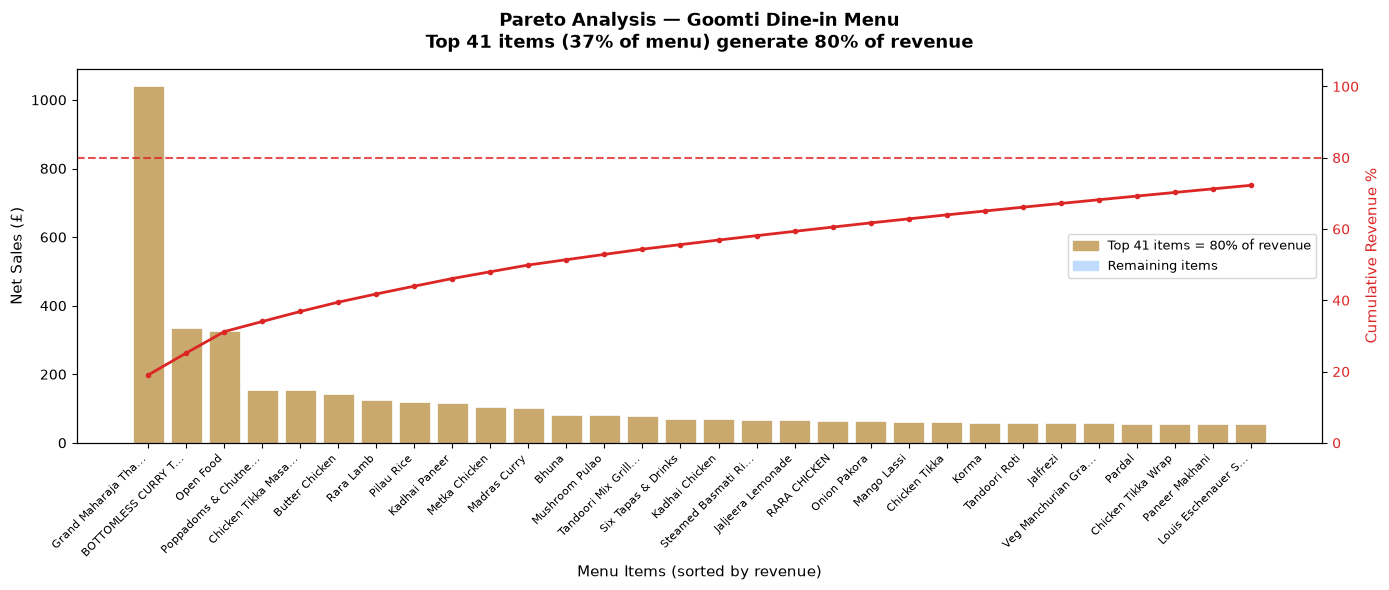

✅ Pareto chart updated


In [9]:
# ── Find true 80% cutoff ──
pareto_80 = df_clean[df_clean['Cumulative_Rev_Pct'] <= 80]
cutoff = len(pareto_80) + 1

print(f"=== TRUE PARETO FINDING ===")
print(f"Items needed to reach 80% revenue: {cutoff}")
print(f"Out of total items: {len(df_clean)}")
print(f"That is {cutoff/len(df_clean)*100:.0f}% of menu generating 80% of revenue")

# ── Replot with correct color cutoff ──
fig, ax1 = plt.subplots(figsize=(14, 6))

top30 = df_clean.head(30)
colors = ['#c9a96e' if i < cutoff else '#bfdbfe' 
          for i in range(len(top30))]

ax1.bar(range(len(top30)), top30['Net_Sales'],
        color=colors, edgecolor='white', linewidth=0.5)

ax1.set_xlabel('Menu Items (sorted by revenue)', fontsize=11)
ax1.set_ylabel('Net Sales (£)', fontsize=11)
ax1.set_xticks(range(len(top30)))
ax1.set_xticklabels([i[:18]+'...' if len(i)>18 else i 
                     for i in top30['Item']],
                    rotation=45, ha='right', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(range(len(top30)), top30['Cumulative_Rev_Pct'],
         color='#dc2626', linewidth=2, marker='o', markersize=3)
ax2.axhline(y=80, color='#dc2626', linestyle='--',
            linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Cumulative Revenue %', fontsize=11, color='#dc2626')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='y', labelcolor='#dc2626')

gold_patch = mpatches.Patch(color='#c9a96e', 
             label=f'Top {cutoff} items = 80% of revenue')
blue_patch = mpatches.Patch(color='#bfdbfe', 
             label='Remaining items')
ax1.legend(handles=[gold_patch, blue_patch], 
           loc='center right', fontsize=9)

plt.title(f'Pareto Analysis — Goomti Dine-in Menu\n'
          f'Top {cutoff} items ({cutoff/len(df_clean)*100:.0f}% of menu) '
          f'generate 80% of revenue',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('pareto_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pareto chart updated")

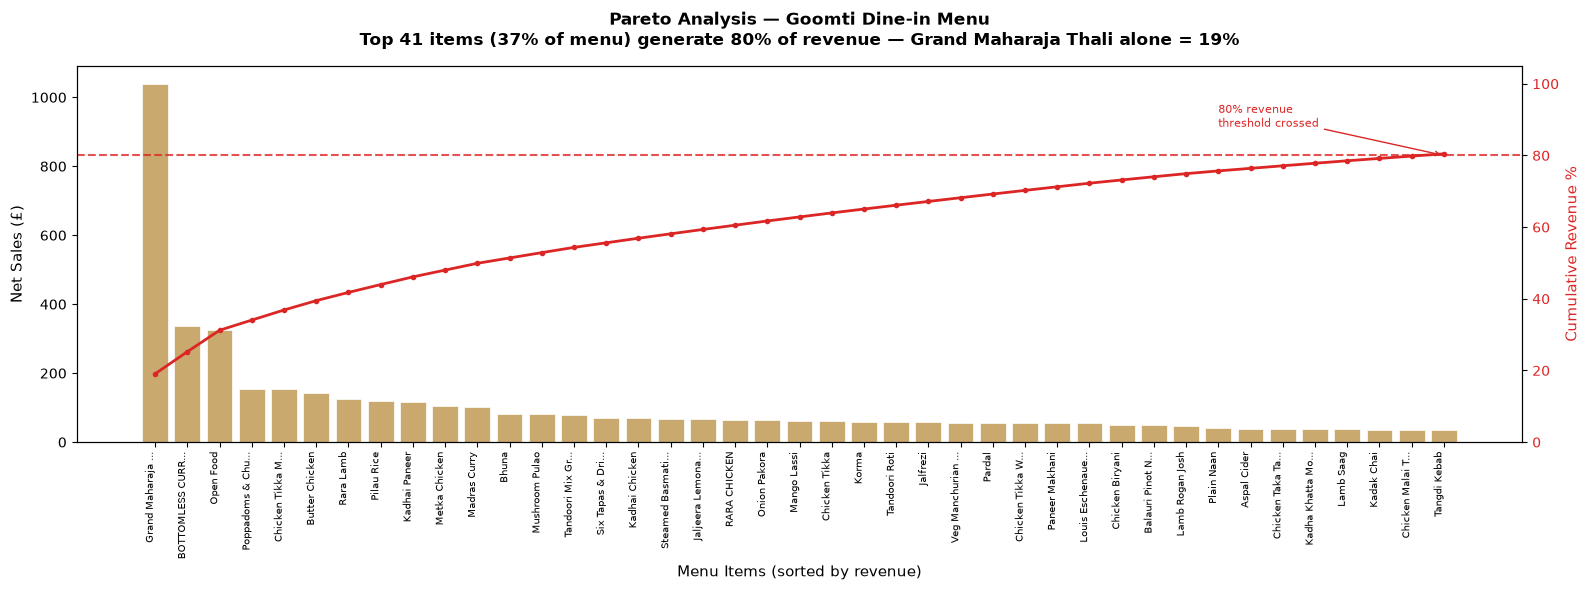

✅ Final Pareto chart saved — 41 items shown


In [10]:
# ── Show all items up to 80% cutoff ──
top41 = df_clean.head(cutoff)

fig, ax1 = plt.subplots(figsize=(16, 6))

colors = ['#c9a96e' if i < cutoff else '#bfdbfe' 
          for i in range(len(top41))]

ax1.bar(range(len(top41)), top41['Net_Sales'],
        color='#c9a96e', edgecolor='white', linewidth=0.5)

ax1.set_xlabel('Menu Items (sorted by revenue)', fontsize=11)
ax1.set_ylabel('Net Sales (£)', fontsize=11)
ax1.set_xticks(range(len(top41)))
ax1.set_xticklabels([i[:15]+'...' if len(i)>15 else i 
                     for i in top41['Item']],
                    rotation=90, ha='right', fontsize=7)

ax2 = ax1.twinx()
ax2.plot(range(len(top41)), top41['Cumulative_Rev_Pct'],
         color='#dc2626', linewidth=2, marker='o', markersize=3)
ax2.axhline(y=80, color='#dc2626', linestyle='--',
            linewidth=1.5, alpha=0.8, label='80% threshold')
ax2.set_ylabel('Cumulative Revenue %', fontsize=11, color='#dc2626')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='y', labelcolor='#dc2626')

# Annotate the 80% crossing point
ax2.annotate('80% revenue\nthreshold crossed', 
             xy=(cutoff-1, 80),
             xytext=(cutoff-8, 88),
             fontsize=8, color='#dc2626',
             arrowprops=dict(arrowstyle='->', color='#dc2626'))

plt.title(f'Pareto Analysis — Goomti Dine-in Menu\n'
          f'Top {cutoff} items ({cutoff/len(df_clean)*100:.0f}% of menu) '
          f'generate 80% of revenue — Grand Maharaja Thali alone = 19%',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('pareto_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Final Pareto chart saved — {cutoff} items shown")

Quadrant counts (excluding Grand Maharaja Thali):
Quadrant
Dog          68
Star         24
Plowhorse    10
Puzzle        9
Name: count, dtype: int64

Thresholds — Revenue: £39.74 | Volume: 5.4


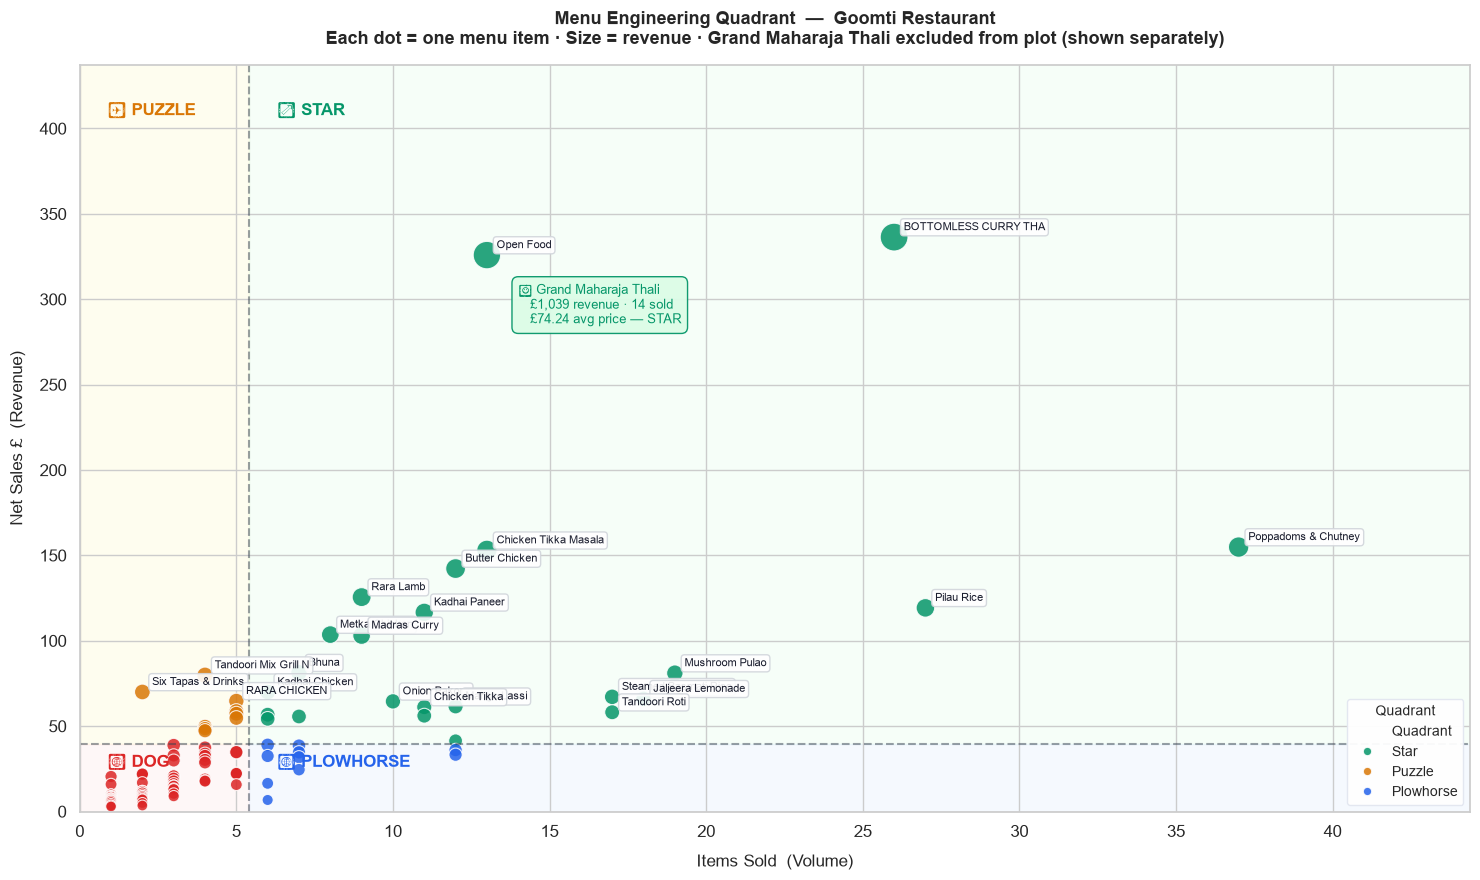

✅ Seaborn quadrant saved


In [14]:
import seaborn as sns

# ── Clean Seaborn Menu Engineering Chart ──
sns.set_theme(style="whitegrid", font_scale=1.1)

# Remove the Grand Maharaja Thali for main plot
# Show it separately as a callout — it's too dominant
df_plot = df_clean[df_clean['Item'] != 'Grand Maharaja Thali'].copy()
gmt = df_clean[df_clean['Item'] == 'Grand Maharaja Thali'].iloc[0]

rev_threshold = df_plot['Net_Sales'].mean()
vol_threshold = df_plot['Items_Sold'].mean()

# Reclassify without GMT
def classify2(row):
    if row['Net_Sales'] >= rev_threshold and row['Items_Sold'] >= vol_threshold:
        return 'Star'
    elif row['Net_Sales'] < rev_threshold and row['Items_Sold'] >= vol_threshold:
        return 'Plowhorse'
    elif row['Net_Sales'] >= rev_threshold and row['Items_Sold'] < vol_threshold:
        return 'Puzzle'
    else:
        return 'Dog'

df_plot['Quadrant'] = df_plot.apply(classify2, axis=1)

print("Quadrant counts (excluding Grand Maharaja Thali):")
print(df_plot['Quadrant'].value_counts())
print(f"\nThresholds — Revenue: £{rev_threshold:.2f} | Volume: {vol_threshold:.1f}")

# ── Plot ──
fig, ax = plt.subplots(figsize=(15, 9))

palette = {
    'Star':      '#059669',
    'Plowhorse': '#2563eb',
    'Puzzle':    '#d97706',
    'Dog':       '#dc2626'
}

sns.scatterplot(
    data=df_plot,
    x='Items_Sold',
    y='Net_Sales',
    hue='Quadrant',
    palette=palette,
    size='Net_Sales',
    sizes=(60, 400),
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

# Label only meaningful items
label_items = df_plot[
    (df_plot['Net_Sales'] > 60) | 
    (df_plot['Items_Sold'] > 15)
]

for _, row in label_items.iterrows():
    ax.annotate(
        row['Item'][:20],
        xy=(row['Items_Sold'], row['Net_Sales']),
        xytext=(7, 5),
        textcoords='offset points',
        fontsize=8,
        color='#1a1d2e',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='#d1d5db',
            alpha=0.9
        )
    )

# Dividing lines
ax.axvline(x=vol_threshold, color='#374151',
           linestyle='--', linewidth=1.5, alpha=0.5)
ax.axhline(y=rev_threshold, color='#374151',
           linestyle='--', linewidth=1.5, alpha=0.5)

# Quadrant background shading
xmax = df_plot['Items_Sold'].max() * 1.2
ymax = df_plot['Net_Sales'].max() * 1.3

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, rev_threshold),
             vol_threshold, ymax,
             color='#fef9c3', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((vol_threshold, rev_threshold),
             xmax, ymax,
             color='#dcfce7', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((0, 0),
             vol_threshold, rev_threshold,
             color='#fee2e2', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((vol_threshold, 0),
             xmax, rev_threshold,
             color='#dbeafe', alpha=0.25, zorder=0))

# Quadrant labels — clean and simple
offset = xmax * 0.02
ax.text(offset, ymax * 0.95,
        '❓ PUZZLE', fontsize=12,
        fontweight='bold', color='#d97706', va='top')
ax.text(vol_threshold + offset, ymax * 0.95,
        '⭐ STAR', fontsize=12,
        fontweight='bold', color='#059669', va='top')
ax.text(offset, rev_threshold * 0.85,
        '🐕 DOG', fontsize=12,
        fontweight='bold', color='#dc2626', va='top')
ax.text(vol_threshold + offset, rev_threshold * 0.85,
        '🐄 PLOWHORSE', fontsize=12,
        fontweight='bold', color='#2563eb', va='top')

# Grand Maharaja Thali callout box
ax.annotate(
    f'★ Grand Maharaja Thali\n'
    f'   £1,039 revenue · 14 sold\n'
    f'   £74.24 avg price — STAR',
    xy=(14, df_plot['Net_Sales'].max() * 0.85),
    fontsize=9,
    color='#059669',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='#dcfce7',
        edgecolor='#059669',
        alpha=0.95
    )
)

ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)
ax.set_xlabel('Items Sold  (Volume)', fontsize=12, labelpad=10)
ax.set_ylabel('Net Sales £  (Revenue)', fontsize=12, labelpad=10)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
# Keep only first 4 (quadrant colors)
ax.legend(
    handles[:4], labels[:4],
    title='Quadrant',
    loc='lower right',
    fontsize=10,
    title_fontsize=10,
    framealpha=0.95,
    edgecolor='#e2e6f0'
)

plt.title(
    'Menu Engineering Quadrant  —  Goomti Restaurant\n'
    'Each dot = one menu item · Size = revenue · '
    'Grand Maharaja Thali excluded from plot (shown separately)',
    fontsize=13, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('menu_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Seaborn quadrant saved")

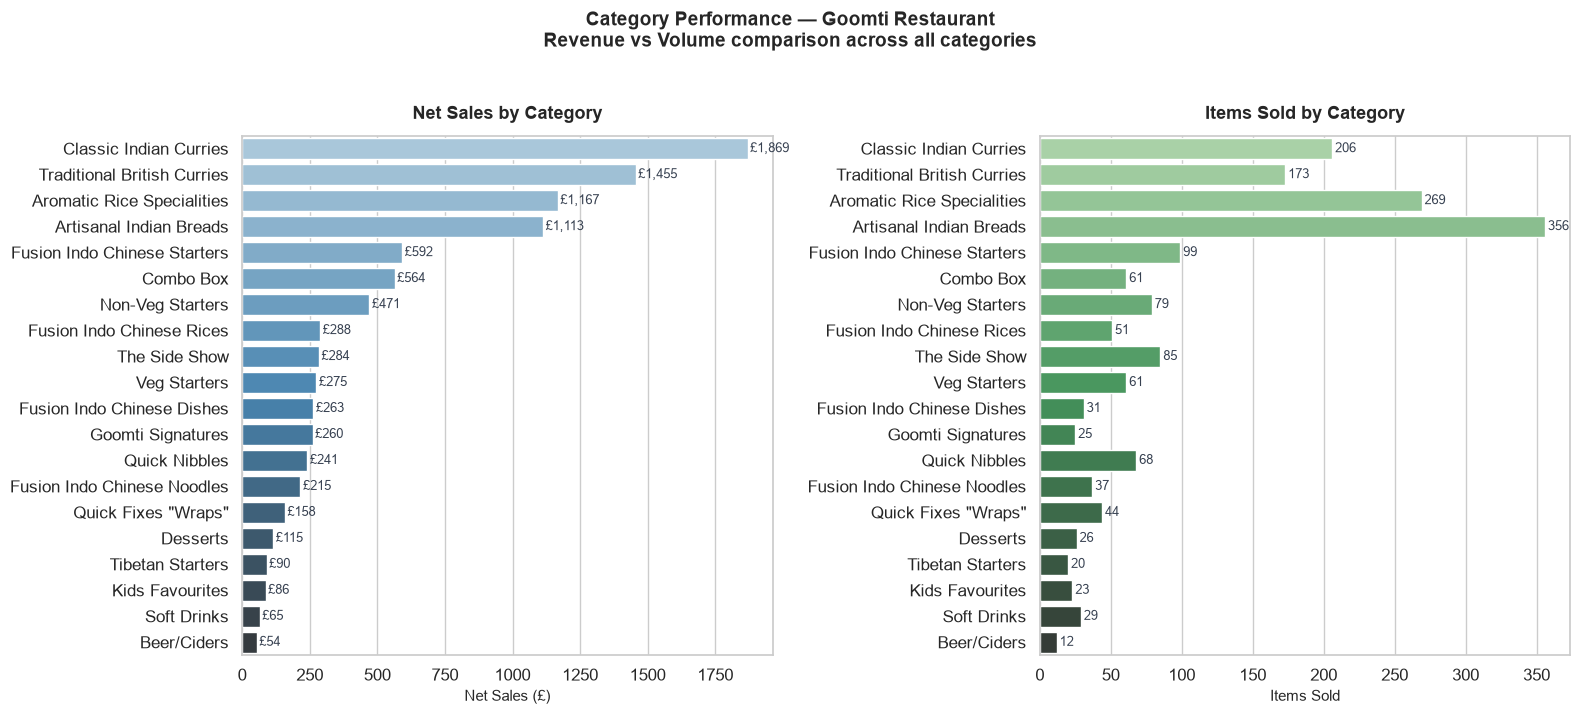

✅ Category chart saved


In [15]:
# ── Category Performance — Seaborn ──
sns.set_theme(style="whitegrid", font_scale=1.1)

# Clean category names
df_categories['Category'] = df_categories['Category'].str.title()
df_categories = df_categories.sort_values('Net_Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 — Revenue by category
colors_cat = sns.color_palette("Blues_d", len(df_categories))
sns.barplot(
    data=df_categories,
    x='Net_Sales',
    y='Category',
    palette=colors_cat,
    ax=axes[0],
    edgecolor='white'
)
axes[0].set_title('Net Sales by Category', 
                   fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Net Sales (£)', fontsize=11)
axes[0].set_ylabel('')

# Add value labels
for i, (val, cat) in enumerate(zip(df_categories['Net_Sales'], 
                                    df_categories['Category'])):
    axes[0].text(val + 10, i, f'£{val:,.0f}', 
                 va='center', fontsize=9, color='#374151')

# Chart 2 — Volume by category
colors_vol = sns.color_palette("Greens_d", len(df_categories))
sns.barplot(
    data=df_categories,
    x='Items_Sold',
    y='Category',
    palette=colors_vol,
    ax=axes[1],
    edgecolor='white'
)
axes[1].set_title('Items Sold by Category', 
                   fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Items Sold', fontsize=11)
axes[1].set_ylabel('')

# Add value labels
for i, val in enumerate(df_categories['Items_Sold']):
    axes[1].text(val + 2, i, str(val), 
                 va='center', fontsize=9, color='#374151')

plt.suptitle('Category Performance — Goomti Restaurant\n'
             'Revenue vs Volume comparison across all categories',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('category_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Category chart saved")

findfont: Failed to find font weight 500, now using 400.


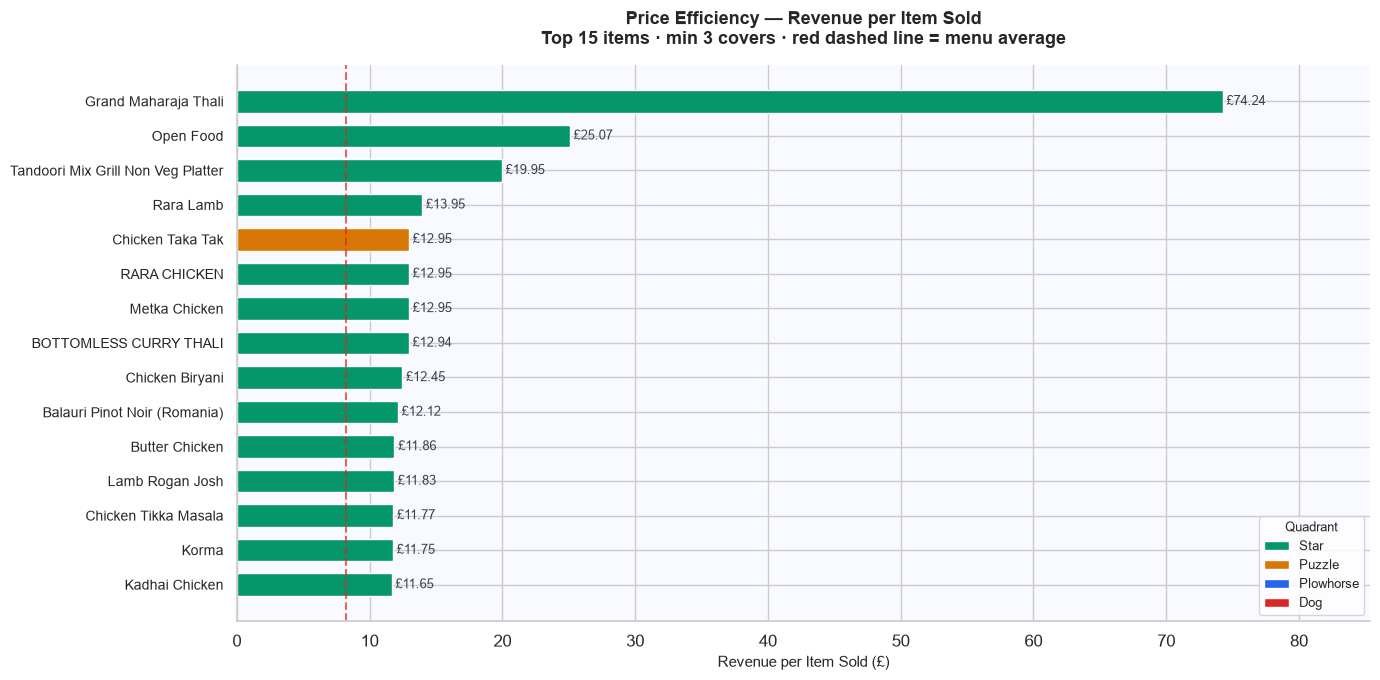

✅ Price efficiency chart saved


In [16]:
# ── Price Efficiency — Revenue per item sold ──
sns.set_theme(style="whitegrid", font_scale=1.1)

# Top 15 by revenue per item (price efficiency)
df_price = df_clean[df_clean['Items_Sold'] >= 3].copy()
df_price = df_price.sort_values('Rev_Per_Item', 
                                 ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))

# Color by quadrant
color_map = {
    'Star': '#059669',
    'Plowhorse': '#2563eb',
    'Puzzle': '#d97706',
    'Dog': '#dc2626'
}
bar_colors = [color_map.get(
    df_clean[df_clean['Item']==item]['Quadrant'].values[0].split()[0], 
    '#6b7280') for item in df_price['Item']]

bars = ax.barh(range(len(df_price)), 
               df_price['Rev_Per_Item'],
               color=bar_colors, 
               edgecolor='white',
               height=0.65)

# Value labels
for i, (val, item) in enumerate(zip(df_price['Rev_Per_Item'], 
                                     df_price['Item'])):
    ax.text(val + 0.3, i, f'£{val:.2f}', 
            va='center', fontsize=9, 
            color='#374151', fontweight='500')

ax.set_yticks(range(len(df_price)))
ax.set_yticklabels(df_price['Item'], fontsize=10)
ax.set_xlabel('Revenue per Item Sold (£)', fontsize=11)
ax.axvline(x=df_clean['Rev_Per_Item'].mean(), 
           color='#dc2626', linestyle='--', 
           linewidth=1.5, alpha=0.7,
           label=f"Avg £{df_clean['Rev_Per_Item'].mean():.2f}")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#059669', label='Star'),
    Patch(facecolor='#d97706', label='Puzzle'),
    Patch(facecolor='#2563eb', label='Plowhorse'),
    Patch(facecolor='#dc2626', label='Dog'),
]
ax.legend(handles=legend_elements, 
          loc='lower right', fontsize=9,
          title='Quadrant', title_fontsize=9)

ax.set_xlim(0, df_price['Rev_Per_Item'].max() * 1.15)
ax.invert_yaxis()
ax.set_facecolor('#f8faff')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Price Efficiency — Revenue per Item Sold\n'
          'Top 15 items · min 3 covers · '
          'red dashed line = menu average',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('price_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Price efficiency chart saved")

In [17]:
# ── Business Recommendations Summary ──
print("=" * 60)
print("   MENU ENGINEERING REPORT — GOOMTI RESTAURANT")
print("=" * 60)

print(f"""
📊 DATASET SUMMARY
{'─' * 40}
Total menu items analysed : {len(df_clean)}
Total dine-in covers      : {df_clean['Items_Sold'].sum()}
Total dine-in net sales   : £{df_clean['Net_Sales'].sum():,.2f}
Analysis period           : May–June 2026

🔍 OUTLIER HANDLING
{'─' * 40}
Cold Takeaway items (£0 revenue) : Removed (business logic)
IQR statistical outliers         : Kept (top performers)
Reason: IQR outliers = £{iqr_outliers['Net_Sales'].sum():,.2f} 
        ({iqr_outliers['Net_Sales'].sum()/df_clean['Net_Sales'].sum()*100:.0f}% of total revenue)

📈 PARETO FINDING
{'─' * 40}
Items generating 80% of revenue  : {cutoff} out of {len(df_clean)}
That is {cutoff/len(df_clean)*100:.0f}% of menu = 80% of revenue
(Weaker than classic 20/80 — menu too broad)
Grand Maharaja Thali alone = 19% of all dine-in revenue

⭐ QUADRANT RESULTS
{'─' * 40}""")

for q in ['Star', 'Puzzle', 'Plowhorse', 'Dog']:
    emoji = {'Star':'⭐','Puzzle':'❓','Plowhorse':'🐄','Dog':'🐕'}[q]
    count = len(df_plot[df_plot['Quadrant']==q])
    rev = df_plot[df_plot['Quadrant']==q]['Net_Sales'].sum()
    print(f"{emoji} {q:12} : {count:3} items | £{rev:,.2f} revenue")

print(f"""
💡 BUSINESS RECOMMENDATIONS
{'─' * 40}
1. PROTECT Stars: Chicken Tikka Masala, Butter Chicken,
   Pilau Rice — these drive consistent revenue + volume.
   Feature prominently on menu. Train staff to upsell.

2. REPRICE Plowhorses: Artisanal Breads (356 sold, £1,113)
   A 15% price increase on breads = +£167/month extra.
   Customers clearly love them — price elasticity is low.

3. MARKET Puzzles: Goomti Signature dishes avg £13.31
   but low covers. Better menu placement + staff 
   recommendations could double their volume.

4. REVIEW Dogs: 48 low-performing items occupy menu space.
   Reducing to top 70 items would simplify kitchen ops
   and improve speed of service.

5. PROTECT Grand Maharaja Thali at all costs:
   14 covers = £1,039 (19% of dine-in revenue).
   At £74.24 avg it is irreplaceable. Never discount it.
""")
print("=" * 60)
print("✅ Analysis complete — 4 charts saved to project folder")
print("=" * 60)

   MENU ENGINEERING REPORT — GOOMTI RESTAURANT

📊 DATASET SUMMARY
────────────────────────────────────────
Total menu items analysed : 112
Total dine-in covers      : 615
Total dine-in net sales   : £5,449.98
Analysis period           : May–June 2026

🔍 OUTLIER HANDLING
────────────────────────────────────────
Cold Takeaway items (£0 revenue) : Removed (business logic)
IQR statistical outliers         : Kept (top performers)
Reason: IQR outliers = £2,277.23 
        (42% of total revenue)

📈 PARETO FINDING
────────────────────────────────────────
Items generating 80% of revenue  : 41 out of 112
That is 37% of menu = 80% of revenue
(Weaker than classic 20/80 — menu too broad)
Grand Maharaja Thali alone = 19% of all dine-in revenue

⭐ QUADRANT RESULTS
────────────────────────────────────────
⭐ Star         :  24 items | £2,555.25 revenue
❓ Puzzle       :   9 items | £530.91 revenue
🐄 Plowhorse    :  10 items | £293.45 revenue
🐕 Dog          :  68 items | £1,031.02 revenue

💡 BUSINESS REC

In [18]:
# ╔══════════════════════════════════════════════════════════╗
# ║     PROJECT 2: MENU ENGINEERING & REVENUE ANALYSIS      ║
# ║     Restaurant : Goomti Indian Restaurant               ║
# ║     Analyst    : [Your Name]                            ║
# ║     Date       : June 2026                              ║
# ║     Tools      : Python, Pandas, Matplotlib, Seaborn    ║
# ╚══════════════════════════════════════════════════════════╝

"""
PROJECT OVERVIEW
────────────────────────────────────────────────────────────
This notebook performs a full Menu Engineering analysis on 
Goomti Restaurant's dine-in sales data (May–June 2026).

TECHNIQUES USED:
1. Data cleaning — business logic outlier removal
2. IQR statistical outlier detection & decision making
3. Pareto 80/20 analysis with cumulative revenue curve
4. Menu Engineering quadrant (Stars/Puzzles/Plowhorses/Dogs)
5. Category performance analysis
6. Price efficiency analysis (revenue per cover)

FILES USED:
- dim_menu_items.csv   → 112 dine-in menu items
- dim_categories.csv   → 20 category-level aggregates

OUTPUT FILES:
- pareto_chart.png
- menu_quadrant.png
- category_performance.png
- price_efficiency.png

KEY FINDINGS:
- Grand Maharaja Thali = 19% of all dine-in revenue
- 37% of menu generates 80% of revenue (weaker than 20/80)
- 68 Dog items should be reviewed for removal
- Artisanal Breads are underpriced (356 sold, only £3.13 avg)
"""

print("✅ Project 2 — Menu Engineering & Revenue Analysis")
print("✅ Goomti Restaurant | June 2026")

✅ Project 2 — Menu Engineering & Revenue Analysis
✅ Goomti Restaurant | June 2026


In [19]:
# ── Save final enriched dataset ──
output_cols = ['Item', 'Category', 'Items_Sold', 'Net_Sales',
               'Avg_Price', 'Rev_Per_Item', 'Rev_Share_Pct',
               'Cumulative_Rev_Pct', 'Quadrant']

df_final = df_clean[output_cols].copy()
df_final.to_csv('menu_analysis_output.csv', index=False)

print("✅ Final output saved: menu_analysis_output.csv")
print(f"\nFile contains {len(df_final)} items with quadrant classifications")
print(f"\nSaved files in your project folder:")
print("  📊 pareto_chart.png")
print("  📊 menu_quadrant.png")
print("  📊 category_performance.png")
print("  📊 price_efficiency.png")
print("  📄 menu_analysis_output.csv")
print("  📓 Goomti_Menu_Engineering.ipynb")

✅ Final output saved: menu_analysis_output.csv

File contains 112 items with quadrant classifications

Saved files in your project folder:
  📊 pareto_chart.png
  📊 menu_quadrant.png
  📊 category_performance.png
  📊 price_efficiency.png
  📄 menu_analysis_output.csv
  📓 Goomti_Menu_Engineering.ipynb
